# Getting the data and data cleaning

In [ ]:
!ls /root/.cache/kagglehub/datasets/algozee/financial-transaction-fraud-dataset/versions/1

FraudShield_Banking_Data.csv


In [ ]:
import pandas as pd

df = pd.read_csv(path+ '/FraudShield_Banking_Data.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Transaction_ID                         49997 non-null  float64
 1   Customer_ID                            49990 non-null  float64
 2   Transaction_Amount (in Million)        49991 non-null  float64
 3   Transaction_Time                       49991 non-null  object 
 4   Transaction_Date                       49997 non-null  object 
 5   Transaction_Type                       49996 non-null  object 
 6   Merchant_ID                            49993 non-null  float64
 7   Merchant_Category                      49991 non-null  object 
 8   Transaction_Location                   49994 non-null  object 
 9   Customer_Home_Location                 49996 non-null  object 
 10  Distance_From_Home                     49998 non-null  float64
 11  De

### Discretizando 'Transaction_Time'

In [ ]:
# Convert 'Transaction_Time' from 'HH:MM' string to minutes from midnight (numerical)
# Ensure 'Transaction_Time' is clean of any non-string or NaN values that cannot be parsed
# For robustness, we will fill any potential NaNs in Transaction_Time with '00:00' before conversion
df['Transaction_Time_Temp'] = df['Transaction_Time'].fillna('00:00').astype(str)

df['Transaction_Minutes'] = df['Transaction_Time_Temp'].apply(
    lambda x: int(x.split(':')[0]) * 60 + int(x.split(':')[1])
)

# Initialize KBinsDiscretizer with 10 bins and 'kmeans' strategy
discretizer_time = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='kmeans', subsample=None, random_state=42)

# Apply discretizer to 'Transaction_Minutes'
df['Discrete_Transaction_Time'] = discretizer_time.fit_transform(df[['Transaction_Minutes']]).astype(int)

# Create descriptive labels for the time bins
bin_edges_time = discretizer_time.bin_edges_[0]
labels_time = []
for i in range(len(bin_edges_time) - 1):
    start_hour = int(bin_edges_time[i] // 60)
    start_minute = int(bin_edges_time[i] % 60)
    end_hour = int(bin_edges_time[i+1] // 60)
    end_minute = int(bin_edges_time[i+1] % 60)
    labels_time.append(f"{start_hour:02d}:{start_minute:02d} - {end_hour:02d}:{end_minute:02d}")

df['Transaction_Time_Labels'] = df['Discrete_Transaction_Time'].map(lambda x: labels_time[x] if x < len(labels_time) else f"> {int(bin_edges_time[-1] // 60):02d}:{int(bin_edges_time[-1] % 60):02d}")

display(df[['Transaction_Time', 'Transaction_Minutes', 'Discrete_Transaction_Time', 'Transaction_Time_Labels']].head())

# Drop the temporary column
df.drop(columns=['Transaction_Time_Temp'], inplace=True, errors='ignore')

,Transaction_Time,Transaction_Minutes,Discrete_Transaction_Time,Transaction_Time_Labels
0,10:54,654,4,09:35 - 11:59
1,19:23,1163,8,19:11 - 21:35
2,10:20,620,4,09:35 - 11:59
3,14:11,851,5,11:59 - 14:23
4,04:12,252,1,02:23 - 04:47


## Label into numeric type for future inferences

In [ ]:
df['Fraud_Label'].unique()

array(['Normal', 'Fraud', nan], dtype=object)

In [ ]:
import numpy as np

def fraud_label_to_int(value) -> int:

  if value == 'Normal':
    return 0
  if value == 'Fraud':
    return 1
  else:
    np.nan



In [ ]:
df['Fraud_Label'] = df['Fraud_Label'].apply(fraud_label_to_int)

In [ ]:
df['Fraud_Label'].unique()

array([ 0.,  1., nan])

In [ ]:
df.head()

,Transaction_ID,Customer_ID,Transaction_Amount (in Million),Transaction_Time,Transaction_Date,Transaction_Type,Merchant_ID,Merchant_Category,Transaction_Location,Customer_Home_Location,...,Daily_Transaction_Count,Weekly_Transaction_Count,Avg_Transaction_Amount (in Million),Max_Transaction_Last_24h (in Million),Is_International_Transaction,Is_New_Merchant,Failed_Transaction_Count,Unusual_Time_Transaction,Previous_Fraud_Count,Fraud_Label
0,431438.0,24239.0,6.0,10:54,2025-03-08,POS,97028.0,ATM,Singapore,Lahore,...,4.0,17.0,2.0,4.0,Yes,Yes,0.0,No,1.0,0.0
1,902451.0,77250.0,9.0,19:23,2025-01-17,ATM,27515.0,ATM,Singapore,Lahore,...,4.0,9.0,5.0,8.0,Yes,Yes,1.0,No,1.0,0.0
2,223410.0,34294.0,3.0,10:20,2025-04-30,POS,13810.0,Electronics,Faisalabad,Faisalabad,...,5.0,18.0,5.0,8.0,Yes,No,0.0,Yes,1.0,0.0
3,145626.0,92041.0,1.0,14:11,2025-02-21,Online,10501.0,Grocery,London,Karachi,...,6.0,18.0,5.0,1.0,No,Yes,2.0,Yes,1.0,0.0
4,414637.0,71578.0,1.0,04:12,2025-04-11,Online,53569.0,Electronics,Singapore,Islamabad,...,3.0,18.0,4.0,3.0,No,Yes,1.0,No,1.0,0.0


## Dealing with categorical features for data visualization

In [ ]:
df['Transaction_Type'].unique()

array(['POS', 'ATM', 'Online', nan], dtype=object)

In [ ]:
from sklearn.impute import SimpleImputer

imputer_trasaction = SimpleImputer(strategy = 'constant', fill_value= 'missing')
imputer_trasaction.fit(df[['Transaction_Type']])

SimpleImputer(fill_value='missing', strategy='constant')

In [ ]:
df['Transaction_Type'] = imputer_trasaction.transform(df[['Transaction_Type']]).ravel()

In [ ]:
df['Transaction_Type'].unique()

array(['POS', 'ATM', 'Online', 'missing'], dtype=object)

In [ ]:
imputer_trasaction.fit(df[['Merchant_Category']])
df['Merchant_Category'] = imputer_trasaction.transform(df[['Merchant_Category']]).ravel()

In [ ]:
imputer_trasaction.fit(df[['Transaction_Location']])
df['Transaction_Location'] = imputer_trasaction.transform(df[['Transaction_Location']]).ravel()

In [ ]:
import numpy as np

# Identify object columns that still have missing values and haven't been processed yet
object_columns = df.select_dtypes(include='object').columns
processed_columns = ['Transaction_Type', 'Merchant_Category', 'Transaction_Location'] # These were already processed

columns_to_impute = [col for col in object_columns if col not in processed_columns]

for col in columns_to_impute:
    if df[col].isnull().any(): # Only impute if there are actually missing values
        print(f"Imputing missing values in column: {col}")
        imputer_trasaction.fit(df[[col]])
        df[col] = imputer_trasaction.transform(df[[col]]).ravel()
    else:
        print(f"Column {col} has no missing values or already processed. Skipping imputation.")

df.info()

Imputing missing values in column: Transaction_Time
Imputing missing values in column: Transaction_Date
Imputing missing values in column: Customer_Home_Location
Imputing missing values in column: IP_Address
Imputing missing values in column: Card_Type
Imputing missing values in column: Is_International_Transaction
Imputing missing values in column: Is_New_Merchant
Imputing missing values in column: Unusual_Time_Transaction
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Transaction_ID                         49997 non-null  float64
 1   Customer_ID                            49990 non-null  float64
 2   Transaction_Amount (in Million)        49991 non-null  float64
 3   Transaction_Time                       50000 non-null  object 
 4   Transaction_Date                       50000 non-n

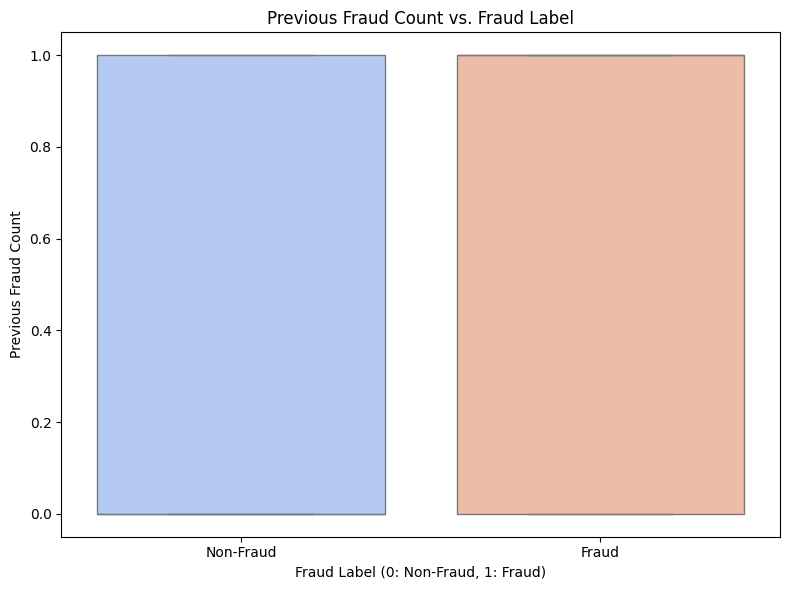

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Fraud_Label', y='Previous_Fraud_Count', palette='coolwarm', hue='Fraud_Label', legend=False)
plt.title('Previous Fraud Count vs. Fraud Label')
plt.xlabel('Fraud Label (0: Non-Fraud, 1: Fraud)')
plt.ylabel('Previous Fraud Count')
plt.xticks([0, 1], ['Non-Fraud', 'Fraud'])
plt.tight_layout()
plt.show()

In [ ]:
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'], errors='coerce')
df['Transaction_Time'] = pd.to_datetime(df['Transaction_Time'], errors='coerce').dt.strftime('%H:%M')
df.info()

/tmp/ipykernel_5036/2471047292.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Transaction_Time'] = pd.to_datetime(df['Transaction_Time'], errors='coerce').dt.strftime('%H:%M')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   Transaction_ID                         49997 non-null  float64       
 1   Customer_ID                            49990 non-null  float64       
 2   Transaction_Amount (in Million)        49991 non-null  float64       
 3   Transaction_Time                       49991 non-null  object        
 4   Transaction_Date                       49997 non-null  datetime64[ns]
 5   Transaction_Type                       50000 non-null  object        
 6   Merchant_ID                            49993 non-null  float64       
 7   Merchant_Category                      50000 non-null  object        
 8   Transaction_Location                   50000 non-null  object        
 9   Customer_Home_Location                 50000 non-null  object

# Exploratory data analys to understand the data set

## Exploring the frauds

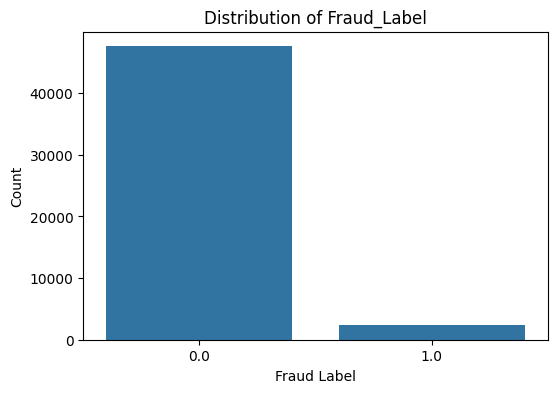

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Fraud_Label')
plt.title('Distribution of Fraud_Label')
plt.xlabel('Fraud Label')
plt.ylabel('Count')
plt.show()


In [ ]:
fraud_total

np.int64(2423)

In [ ]:
non_fraude_total

np.int64(47573)

## Transaction type influences Fraud?

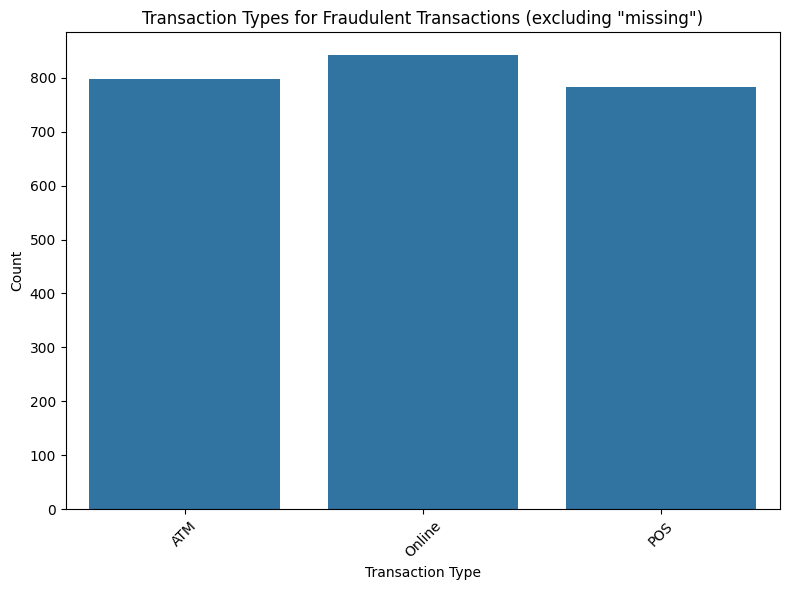

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.countplot(x=df['Transaction_Type'][(df['Fraud_Label'] == 1) & (df['Transaction_Type'] != "missing")])
plt.title('Transaction Types for Fraudulent Transactions (excluding "missing")')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Merchant Type type influences Fraud?

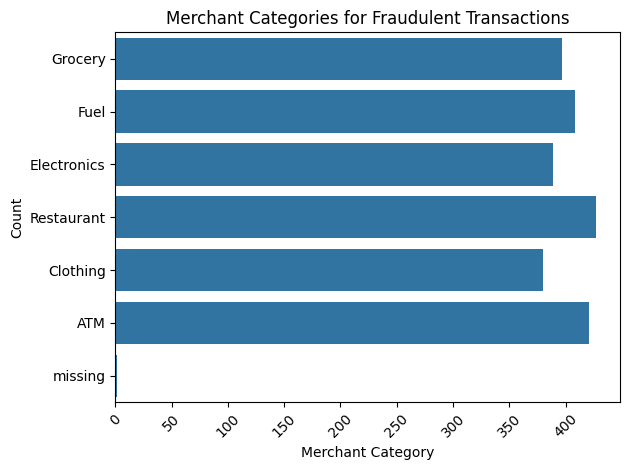

In [ ]:
import matplotlib.pyplot as plt

sns.countplot(df['Merchant_Category'][df['Fraud_Label'] == 1])
plt.title('Merchant Categories for Fraudulent Transactions')
plt.xlabel('Merchant Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Location influences Fraud?

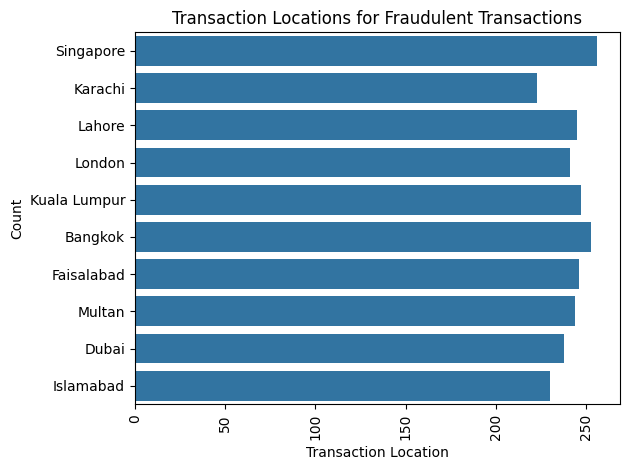

In [ ]:
import matplotlib.pyplot as plt

sns.countplot(df['Transaction_Location'][df['Fraud_Label'] == 1])
plt.title('Transaction Locations for Fraudulent Transactions')
plt.xlabel('Transaction Location')
plt.ylabel('Count')
plt.xticks(rotation=90) # Rotate labels for better visibility if many locations
plt.tight_layout()
plt.show()

In [ ]:
df['Distance_From_Home']

,Distance_From_Home
0,466.0
1,215.0
2,216.0
3,408.0
4,209.0
...,...
49995,571.0
49996,433.0
49997,161.0
49998,317.0


In [ ]:
from sklearn.preprocessing import KBinsDiscretizer
import numpy as np


# Initialize KBinsDiscretizer with 10 bins, strategy 'kmeans' to find optimal bins, and encode as ordinal
discretizer = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='kmeans', subsample=None, random_state=42)

# Reshape the column for fit_transform and apply the discretizer
df['Discrete_Distance_From_Home'] = discretizer.fit_transform(df[['Distance_From_Home']]).astype(int)

# Create descriptive labels for the bins
bin_edges = discretizer.bin_edges_[0]
labels = []
for i in range(len(bin_edges) - 1):
    labels.append(f"{bin_edges[i]:.2f} - {bin_edges[i+1]:.2f}")

df['Distance_From_Home_Labels'] = df['Discrete_Distance_From_Home'].map(lambda x: labels[x] if x < len(labels) else f"> {bin_edges[-1]:.2f}")

df[['Distance_From_Home', 'Discrete_Distance_From_Home', 'Distance_From_Home_Labels']].head()

,Distance_From_Home,Discrete_Distance_From_Home,Distance_From_Home_Labels
0,466.0,7,419.31 - 479.28
1,215.0,3,180.68 - 240.64
2,216.0,3,180.68 - 240.64
3,408.0,6,359.65 - 419.31
4,209.0,3,180.68 - 240.64


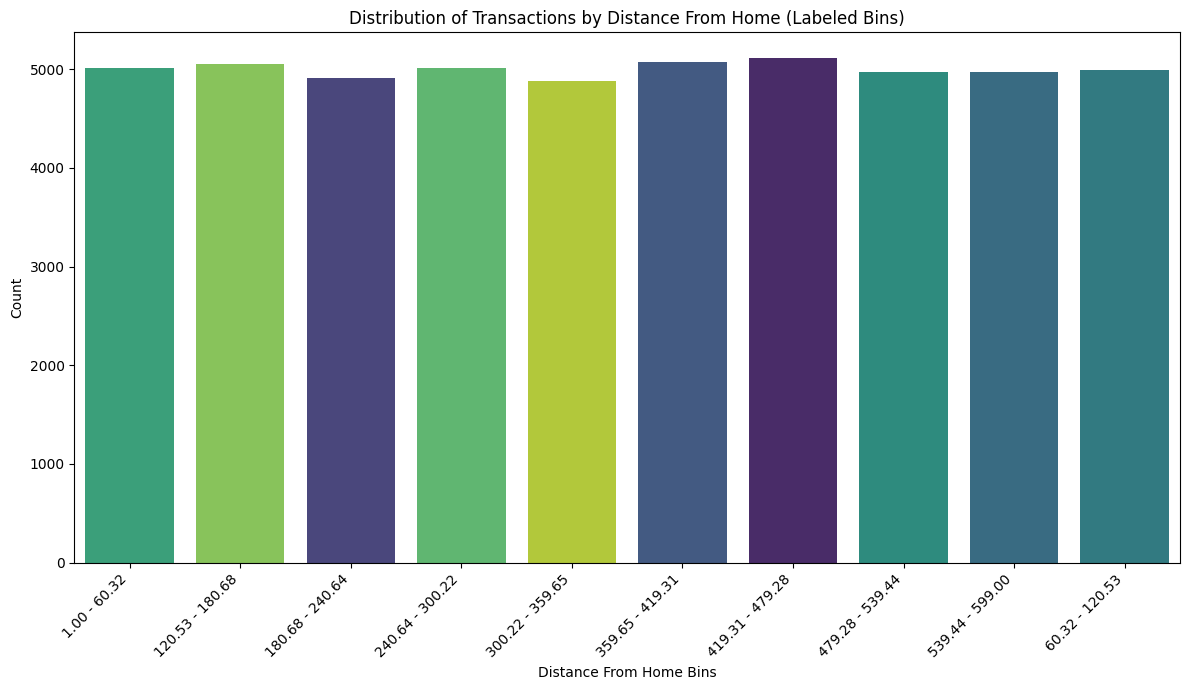

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.countplot(data=df, x='Distance_From_Home_Labels', hue='Distance_From_Home_Labels', palette='viridis', order=sorted(df['Distance_From_Home_Labels'].unique()), legend=False)
plt.title('Distribution of Transactions by Distance From Home (Labeled Bins)')
plt.xlabel('Distance From Home Bins')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

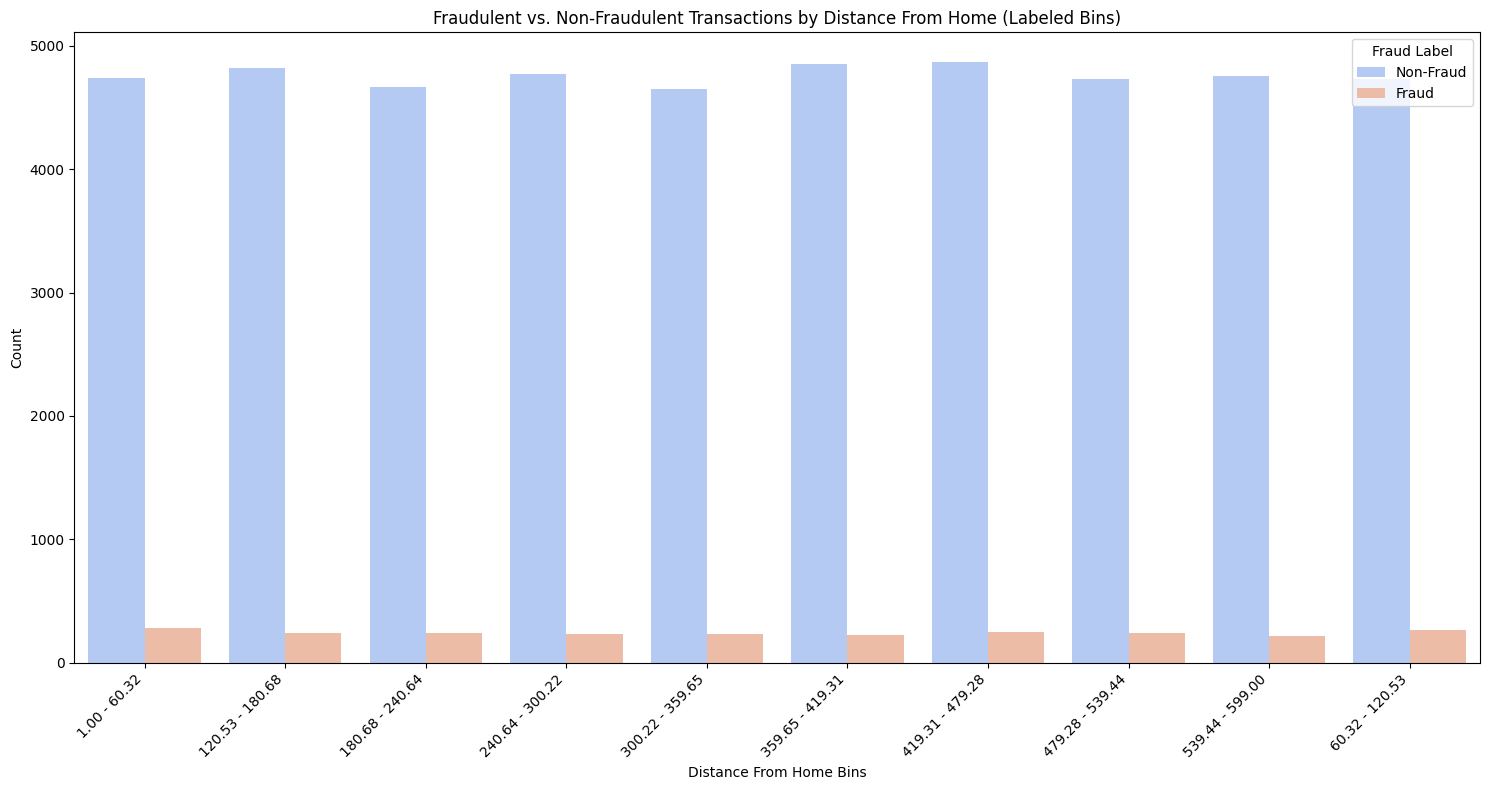

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 8))
sns.countplot(data=df, x='Distance_From_Home_Labels', hue='Fraud_Label', palette='coolwarm', order=sorted(df['Distance_From_Home_Labels'].unique()))
plt.title('Fraudulent vs. Non-Fraudulent Transactions by Distance From Home (Labeled Bins)')
plt.xlabel('Distance From Home Bins')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Fraud Label', labels=['Non-Fraud', 'Fraud'])
plt.tight_layout()
plt.show()

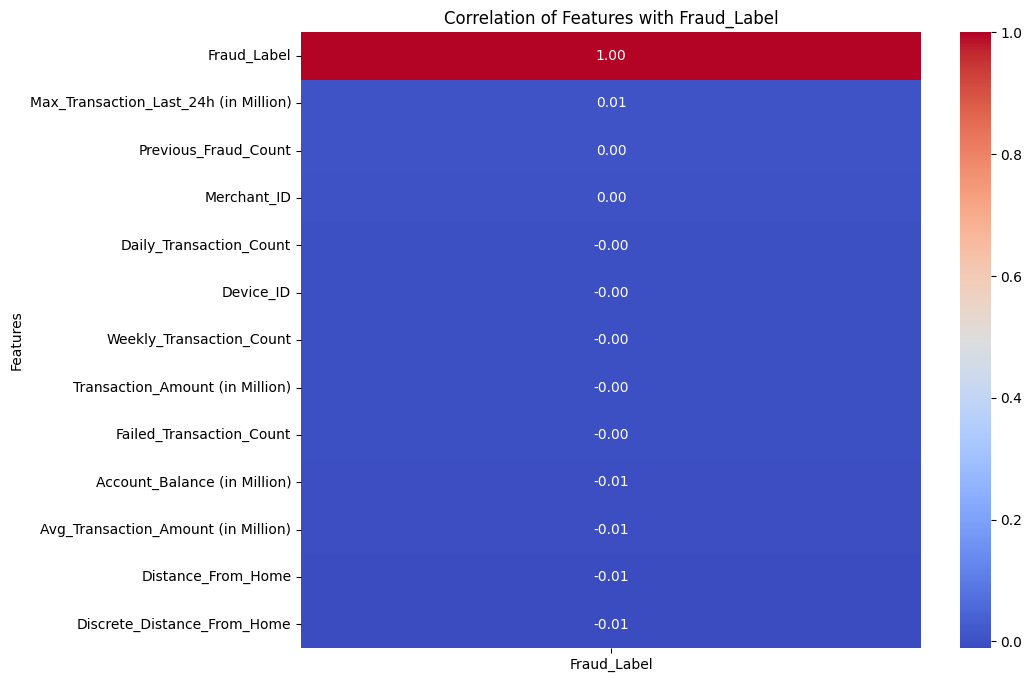

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Selecionar apenas as colunas numéricas para a correlação
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Excluir Transaction_ID e Customer_ID se não forem relevantes para a correlação com a fraude
# Pois são identificadores e não características que influenciam a fraude diretamente
features_for_corr = [col for col in numerical_cols if col not in ['Transaction_ID', 'Customer_ID']]

# Calcular a matriz de correlação apenas para as features selecionadas e Fraud_Label
correlation_matrix = df[features_for_corr].corr()

# Extrair a correlação das features com Fraud_Label
fraud_correlation = correlation_matrix['Fraud_Label'].sort_values(ascending=False)

# Visualizar a correlação com Fraud_Label
plt.figure(figsize=(10, 8))
sns.heatmap(fraud_correlation.to_frame(), annot=True, cmap='coolwarm', fmt=".2f", cbar=True)
plt.title('Correlation of Features with Fraud_Label')
plt.ylabel('Features')
plt.show()

## Descartando os valores de baixa correlação

In [ ]:
all_df_features = df.columns.tolist()
excluded_features = [col for col in all_df_features if col not in features_for_corr]

print("Features in df not present in features_for_corr:")

for feature in excluded_features:
    print(f"- {feature}")

Features in df not present in features_for_corr:
- Transaction_ID
- Customer_ID
- Transaction_Time
- Transaction_Date
- Transaction_Type
- Merchant_Category
- Transaction_Location
- Customer_Home_Location
- IP_Address
- Card_Type
- Is_International_Transaction
- Is_New_Merchant
- Unusual_Time_Transaction
- Distance_From_Home_Labels


## New Merchant influences Fraud?

<Axes: xlabel='Is_New_Merchant', ylabel='count'>

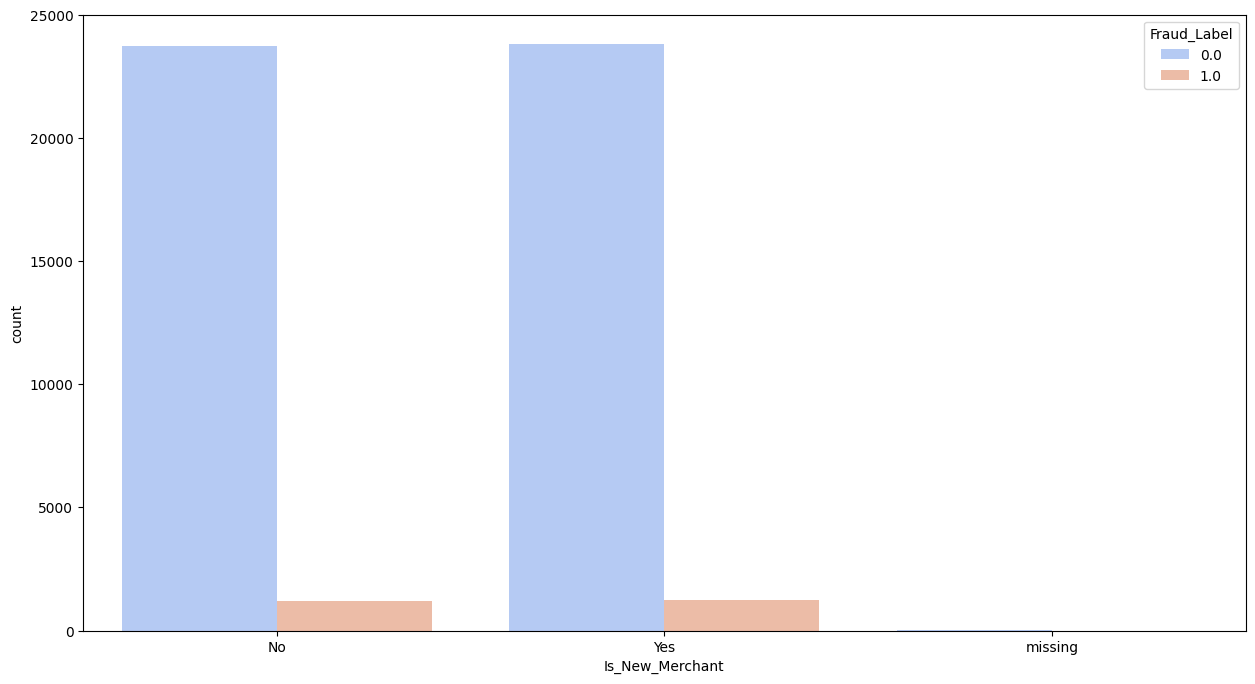

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 8))
sns.countplot(data=df, x='Is_New_Merchant', hue='Fraud_Label', palette='coolwarm', order=sorted(df['Is_New_Merchant'].unique()))


## Unusual_Time_Transaction influences Fraud

<Axes: xlabel='Unusual_Time_Transaction', ylabel='count'>

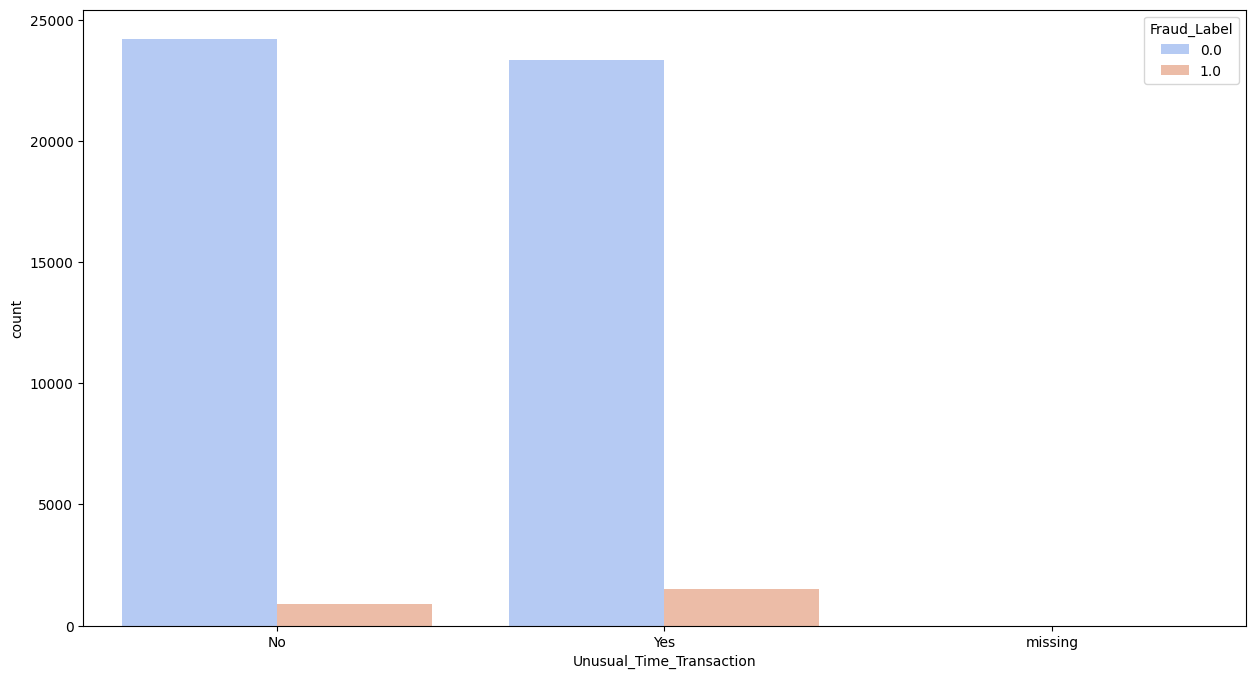

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 8))
sns.countplot(data=df, x='Unusual_Time_Transaction', hue='Fraud_Label', palette='coolwarm', order=sorted(df['Is_New_Merchant'].unique()))


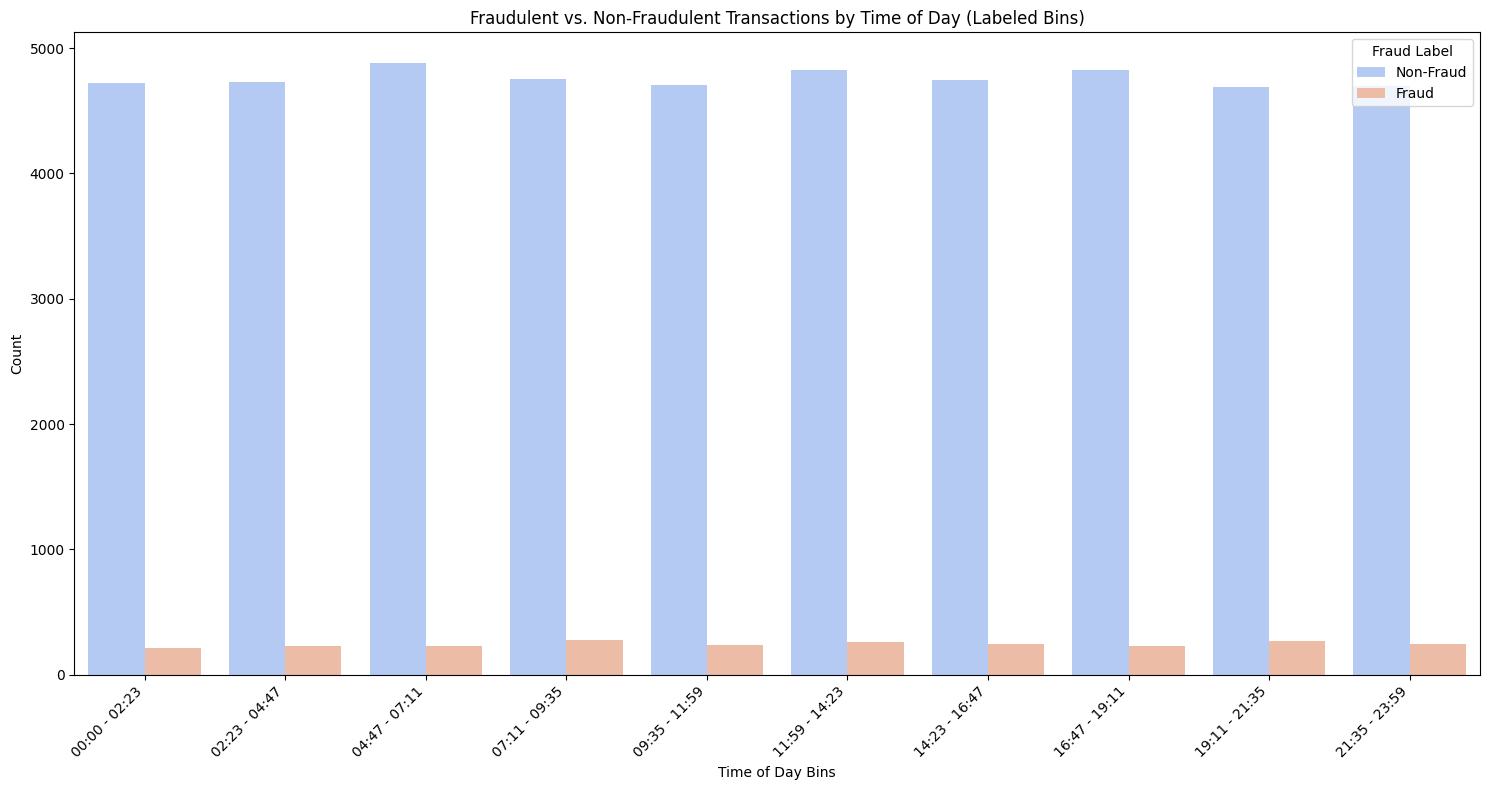

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 8))
sns.countplot(data=df, x='Transaction_Time_Labels', hue='Fraud_Label', palette='coolwarm', order=sorted(df['Transaction_Time_Labels'].unique()))
plt.title('Fraudulent vs. Non-Fraudulent Transactions by Time of Day (Labeled Bins)')
plt.xlabel('Time of Day Bins')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Fraud Label', labels=['Non-Fraud', 'Fraud'])
plt.tight_layout()
plt.show()

# Feature Selection Using chi2

In [ ]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.feature_selection import chi2
import pandas as pd
import numpy as np

# Ensure Fraud_Label is integer type, as chi2 expects integer labels.
# We previously converted it to float64 and then dropped NaNs, so it should be fine but explicit conversion is safer.
# Add a check for NaNs specifically in 'Fraud_Label' immediately before conversion
if df['Fraud_Label'].isnull().any():
    print("Warning: NaN values found in 'Fraud_Label' before converting to int. Dropping rows with NaN in 'Fraud_Label'.")
    df.dropna(subset=['Fraud_Label'], inplace=True)

df['Fraud_Label'] = df['Fraud_Label'].astype(int)

# Identify categorical features for chi2 test.
# We exclude 'IP_Address' due to its very high cardinality which makes chi2 less meaningful and computationally heavy.
# 'Transaction_Time' and 'Transaction_Date' are also excluded as they are time-related or datetimes and better handled by other methods or their discretized labels.
categorical_features_for_chi2 = [
    'Transaction_Type',
    'Merchant_Category',
    'Transaction_Location',
    'Customer_Home_Location',
    'Card_Type',
    'Is_International_Transaction',
    'Is_New_Merchant',
    'Unusual_Time_Transaction'
]

chi2_scores = []
chi2_p_values = []
feature_names = []

print("Calculating Chi-Squared scores for categorical features...")

for col in categorical_features_for_chi2:
    # OrdinalEncoder to convert categorical strings to numerical integers.
    # handle_unknown='use_encoded_value' with unknown_value=-1 is a robust way to handle new categories,
    # though with prior imputation to 'missing', it should not occur if fit_transform is used correctly.
    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

    # Fit and transform the feature, ensuring it's 2D as expected by encoder
    encoded_feature = encoder.fit_transform(df[[col]])

    # Apply chi2 test. chi2 expects non-negative input for X.
    # Since our categories are encoded as 0, 1, 2... and 'missing' was imputed, values will be non-negative.
    score, p_value = chi2(encoded_feature, df['Fraud_Label'])

    chi2_scores.append(score[0]) # chi2 returns an array, we need the first (and only) element
    chi2_p_values.append(p_value[0]) # Same for p_value
    feature_names.append(col)

# Create a DataFrame to display the results
chi2_df = pd.DataFrame({
    'Feature': feature_names,
    'Chi2_Score': chi2_scores,
    'P_Value': chi2_p_values
})

# Sort by Chi2_Score in descending order to see most influential features first
chi2_df = chi2_df.sort_values(by='Chi2_Score', ascending=False).reset_index(drop=True)

print("\nChi-Squared Test Results for Categorical Features vs. Fraud_Label:")
display(chi2_df)

print("\nInterpretation:")
print("- Higher Chi2 Score: Indicates a stronger statistical dependence between the feature and Fraud_Label.")
print("- Lower P-Value: Indicates that the observed relationship is statistically significant, meaning it's unlikely to have occurred by random chance (typically p-value < 0.05 is considered significant).")

Calculating Chi-Squared scores for categorical features...

Chi-Squared Test Results for Categorical Features vs. Fraud_Label:


,Feature,Chi2_Score,P_Value
0,Is_International_Transaction,90.309000,2.037238e-21
1,Unusual_Time_Transaction,89.654196,2.836465e-21
2,Merchant_Category,0.286861,5.922390e-01
3,Customer_Home_Location,0.272754,6.014903e-01
4,Is_New_Merchant,0.110502,7.395735e-01
5,Card_Type,0.085120,7.704758e-01
6,Transaction_Location,0.074086,7.854786e-01
7,Transaction_Type,0.031461,8.592166e-01



Interpretation:
- Higher Chi2 Score: Indicates a stronger statistical dependence between the feature and Fraud_Label.
- Lower P-Value: Indicates that the observed relationship is statistically significant, meaning it's unlikely to have occurred by random chance (typically p-value < 0.05 is considered significant).


## Preparing data for modeling


In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# 1. Define the target variable 'y'
y = df['Fraud_Label']

# 2. Identify the numerical features
numerical_features = [
    'Transaction_Amount (in Million)',
    'Merchant_ID',
    'Distance_From_Home',
    'Device_ID',
    'Account_Balance (in Million)',
    'Daily_Transaction_Count',
    'Weekly_Transaction_Count',
    'Avg_Transaction_Amount (in Million)',
    'Max_Transaction_Last_24h (in Million)',
    'Failed_Transaction_Count',
    'Previous_Fraud_Count',
    'Discrete_Distance_From_Home',
    'Discrete_Transaction_Time'
]

# 3. Identify the categorical features
categorical_features = [
    'Is_International_Transaction',
    'Unusual_Time_Transaction'
]

# 4. Create the feature DataFrame X
X = df[numerical_features + categorical_features].copy()

# 5. Impute any remaining missing values in numerical features of X using the median strategy
numerical_imputer = SimpleImputer(strategy='median')
X[numerical_features] = numerical_imputer.fit_transform(X[numerical_features])

# 6. Apply One-Hot Encoding to the selected categorical features in X
one_hot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded_categorical_features = one_hot_encoder.fit_transform(X[categorical_features])

# Create a DataFrame from the one-hot encoded features
encoded_categorical_df = pd.DataFrame(
    encoded_categorical_features,
    columns=one_hot_encoder.get_feature_names_out(categorical_features),
    index=X.index
)

# Drop the original categorical columns and concatenate the one-hot encoded features
X = X.drop(columns=categorical_features)
X = pd.concat([X, encoded_categorical_df], axis=1)

# 7. Display the first few rows and the shape of the prepared feature DataFrame X and the target variable y
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print("\nFirst 5 rows of X:")
display(X.head())
print("\nFirst 5 rows of y:")
display(y.head())

Shape of X: (49996, 19)
Shape of y: (49996,)

First 5 rows of X:


,Transaction_Amount (in Million),Merchant_ID,Distance_From_Home,Device_ID,Account_Balance (in Million),Daily_Transaction_Count,Weekly_Transaction_Count,Avg_Transaction_Amount (in Million),Max_Transaction_Last_24h (in Million),Failed_Transaction_Count,Previous_Fraud_Count,Discrete_Distance_From_Home,Discrete_Transaction_Time,Is_International_Transaction_No,Is_International_Transaction_Yes,Is_International_Transaction_missing,Unusual_Time_Transaction_No,Unusual_Time_Transaction_Yes,Unusual_Time_Transaction_missing
0,6.0,97028.0,466.0,363229.0,30.0,4.0,17.0,2.0,4.0,0.0,1.0,7.0,4.0,0.0,1.0,0.0,1.0,0.0,0.0
1,9.0,27515.0,215.0,480487.0,4.0,4.0,9.0,5.0,8.0,1.0,1.0,3.0,8.0,0.0,1.0,0.0,1.0,0.0,0.0
2,3.0,13810.0,216.0,297313.0,38.0,5.0,18.0,5.0,8.0,0.0,1.0,3.0,4.0,0.0,1.0,0.0,0.0,1.0,0.0
3,1.0,10501.0,408.0,948506.0,22.0,6.0,18.0,5.0,1.0,2.0,1.0,6.0,5.0,1.0,0.0,0.0,0.0,1.0,0.0
4,1.0,53569.0,209.0,954201.0,10.0,3.0,18.0,4.0,3.0,1.0,1.0,3.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0



First 5 rows of y:


,Fraud_Label
0,0
1,0
2,0
3,0
4,0


In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets, maintaining class proportionality
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Display the shapes of the resulting datasets
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

print("\nClass distribution in y_train:")
print(y_train.value_counts(normalize=True))

print("\nClass distribution in y_test:")
print(y_test.value_counts(normalize=True))

Shape of X_train: (39996, 19)
Shape of X_test: (10000, 19)
Shape of y_train: (39996,)
Shape of y_test: (10000,)

Class distribution in y_train:
Fraud_Label
0    0.951545
1    0.048455
Name: proportion, dtype: float64

Class distribution in y_test:
Fraud_Label
0    0.9515
1    0.0485
Name: proportion, dtype: float64


# Training logistic regression

In [ ]:
from sklearn.linear_model import LogisticRegression

# Instantiate a LogisticRegression model with balanced class weights
model = LogisticRegression(class_weight='balanced', random_state=42, solver='liblinear', max_iter=1000)

# Train the model using the training data
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Make predictions on the test set
y_pred = model.predict(X_test)

# Predict probabilities for the positive class (class 1)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Print the calculated metrics
print(f"Accuracy Score: {accuracy:.4f}")
print(f"Precision Score: {precision:.4f}")
print(f"Recall Score: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC Score: {roc_auc:.4f}")

Accuracy Score: 0.6339
Precision Score: 0.0645
Recall Score: 0.4845
F1 Score: 0.1138
ROC AUC Score: 0.6008


# Using smote to deal with unbalace



In [ ]:
from imblearn.over_sampling import SMOTE

# Instantiate SMOTE
sm = SMOTE(random_state=42)

# Apply SMOTE to the training data
X_resampled_smote, y_resampled_smote = sm.fit_resample(X_train, y_train)

# Print the shape of the resampled data
print("Shape of X_resampled_smote:", X_resampled_smote.shape)
print("Shape of y_resampled_smote:", y_resampled_smote.shape)

# Print the value counts of y_resampled_smote to confirm class balance
print("\nClass distribution in y_resampled_smote:")
print(y_resampled_smote.value_counts())

Shape of X_resampled_smote: (76116, 19)
Shape of y_resampled_smote: (76116,)

Class distribution in y_resampled_smote:
Fraud_Label
0    38058
1    38058
Name: count, dtype: int64


In [ ]:
from sklearn.linear_model import LogisticRegression

# Instantiate a LogisticRegression model
# As the data has been balanced by SMOTE, class_weight is not explicitly needed.
model_lr_smote = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)

# Train the model using the SMOTE-resampled training data
model_lr_smote.fit(X_resampled_smote, y_resampled_smote)

print("Logistic Regression model (with SMOTE-resampled data) trained successfully.")

Logistic Regression model (with SMOTE-resampled data) trained successfully.


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Make predictions on the test set using the SMOTE-trained model
y_pred_lr_smote = model_lr_smote.predict(X_test)

# Predict probabilities for the positive class (class 1) for the SMOTE-trained model
y_pred_proba_lr_smote = model_lr_smote.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
accuracy_lr_smote = accuracy_score(y_test, y_pred_lr_smote)
precision_lr_smote = precision_score(y_test, y_pred_lr_smote)
recall_lr_smote = recall_score(y_test, y_pred_lr_smote)
f1_lr_smote = f1_score(y_test, y_pred_lr_smote)
roc_auc_lr_smote = roc_auc_score(y_test, y_pred_proba_lr_smote)

# Print the calculated metrics
print("Evaluation Metrics for Logistic Regression with SMOTE Oversampling:")
print(f"Accuracy Score: {accuracy_lr_smote:.4f}")
print(f"Precision Score: {precision_lr_smote:.4f}")
print(f"Recall Score: {recall_lr_smote:.4f}")
print(f"F1 Score: {f1_lr_smote:.4f}")
print(f"ROC AUC Score: {roc_auc_lr_smote:.4f}")

Evaluation Metrics for Logistic Regression with SMOTE Oversampling:
Accuracy Score: 0.6205
Precision Score: 0.0633
Recall Score: 0.4948
F1 Score: 0.1123
ROC AUC Score: 0.6018


## Bayesian *Optimization* on model_lr_smote

---



In [ ]:
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# Define the search space for hyperparameters
space = {
    'C': hp.loguniform('C', -5, 0), # Regularization parameter C (inverse of regularization strength)
    'penalty': hp.choice('penalty', ['l1', 'l2']) # Regularization type
}

# Define the objective function for hyperopt
def objective(params):
    model_lr = LogisticRegression(
        C=params['C'],
        penalty=params['penalty'],
        solver='liblinear', # 'liblinear' supports both l1 and l2 penalties
        max_iter=1000,
        random_state=42
    )

    model_lr.fit(X_resampled_smote, y_resampled_smote)
    y_pred_proba = model_lr.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    # We want to maximize ROC AUC, so we return its negative for minimization
    return {'loss': -roc_auc, 'status': STATUS_OK, 'model': model_lr}

print("Objective function and hyperparameter search space defined.")

Objective function and hyperparameter search space defined.


In [ ]:
trials = Trials()
best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=50, # Number of evaluations
    trials=trials,
    rstate=np.random.default_rng(42) # For reproducibility
)

print("Bayesian optimization complete.")
print("Best hyperparameters found:", best)

# Get the best model from the trials
best_trial = sorted(trials.results, key=lambda x: x['loss'])[0]
best_model = best_trial['model']

print("Best model obtained from optimization:", best_model)

100%|██████████| 50/50 [02:52<00:00,  3.46s/trial, best loss: -0.6027128083167652]
Bayesian optimization complete.
Best hyperparameters found: {'C': np.float64(0.9247240723736498), 'penalty': np.int64(1)}
Best model obtained from optimization: LogisticRegression(C=0.9247240723736498, max_iter=1000, random_state=42,
                   solver='liblinear')


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Make predictions on the test set using the best model from Bayesian optimization
y_pred_optimized = best_model.predict(X_test)

# Predict probabilities for the positive class (class 1)
y_pred_proba_optimized = best_model.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
accuracy_optimized = accuracy_score(y_test, y_pred_optimized)
precision_optimized = precision_score(y_test, y_pred_optimized)
recall_optimized = recall_score(y_test, y_pred_optimized)
f1_optimized = f1_score(y_test, y_pred_optimized)
roc_auc_optimized = roc_auc_score(y_test, y_pred_proba_optimized)

# Print the calculated metrics
print("Evaluation Metrics for Logistic Regression with Bayesian Optimization (SMOTE):")
print(f"Accuracy Score: {accuracy_optimized:.4f}")
print(f"Precision Score: {precision_optimized:.4f}")
print(f"Recall Score: {recall_optimized:.4f}")
print(f"F1 Score: {f1_optimized:.4f}")
print(f"ROC AUC Score: {roc_auc_optimized:.4f}")

Evaluation Metrics for Logistic Regression with Bayesian Optimization (SMOTE):
Accuracy Score: 0.6042
Precision Score: 0.0634
Recall Score: 0.5196
F1 Score: 0.1130
ROC AUC Score: 0.6027


## Salvar DataFrame como CSV

### Subtask:
Utilizar o método `df.to_csv()` para salvar o DataFrame atual em um arquivo CSV, sem incluir o índice do DataFrame.


**Reasoning**:
The subtask is to save the DataFrame `df` to a CSV file named 'fraud_data_processed.csv' without including the index. The `to_csv()` method with `index=False` will achieve this.



In [ ]:
df.to_csv('fraud_data_processed.csv', index=False)
print("DataFrame 'df' successfully saved to 'fraud_data_processed.csv'.")

DataFrame 'df' successfully saved to 'fraud_data_processed.csv'.
